# Breast Cancer Wisconsin

The Breast Cancer Wisconsin Dataset is a foundational collection from the UCI Machine Learning Repository, used extensively in medical and machine learning research for tumor classification. It includes digitized measurements from breast mass samples to distinguish malignant from benign cases, underpinning countless studies in diagnostic modeling and feature analysis.

In [90]:
import kagglehub
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf

## Import the data

In [91]:
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
print("Path to dataset files:", path)
df = pd.read_csv(f'{path}/data.csv')

Path to dataset files: C:\Users\user-pc\.cache\kagglehub\datasets\uciml\breast-cancer-wisconsin-data\versions\2


## Cleaning The Data

In [92]:
df = df.drop(columns=['id', 'Unnamed: 32'])
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
X = df.drop(columns=['diagnosis']).to_numpy()
y = df['diagnosis'].to_numpy()
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (569, 30)
Shape of y: (569,)


## Splitting the Data

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)

Training set shape: (364, 30) (364,)
Validation set shape: (91, 30) (91,)


## Data Normalization

In [94]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## Configure The Model

In [95]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Dense(128, activation='relu', input_shape=(30,)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
  loss='binary_crossentropy',
  metrics=['accuracy'])

c:\Projects\tjabane.thuto.deep-learning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [96]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))
validation_loss, validation_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {validation_loss:.4f}, Test Accuracy: {validation_accuracy:.4f}")

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5549 - loss: 0.6943 - val_accuracy: 0.7253 - val_loss: 0.6254
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8407 - loss: 0.5502 - val_accuracy: 0.8462 - val_loss: 0.5275
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9038 - loss: 0.4613 - val_accuracy: 0.8901 - val_loss: 0.4604
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9203 - loss: 0.3996 - val_accuracy: 0.9011 - val_loss: 0.4112
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9258 - loss: 0.3539 - val_accuracy: 0.9121 - val_loss: 0.3731
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9341 - loss: 0.3184 - val_accuracy: 0.9121 - val_loss: 0.3436
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9368 - loss: 0.2908 - val_accuracy: 0.9121 - val_loss: 0.3198
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9368 - loss: 0.2683 - val_accuracy: 0.9121 - val_loss

## Training Metrics

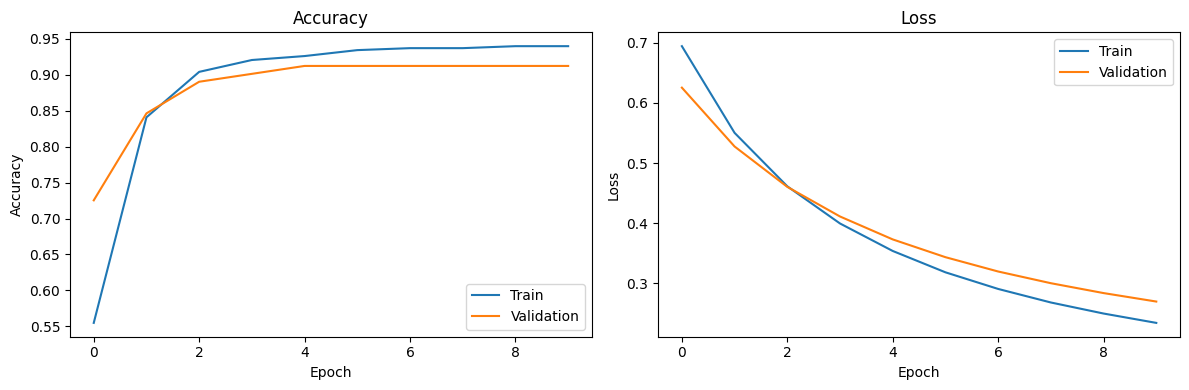

In [97]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()